In [2]:
require(data.table)
require(tidyverse)
require(dplyr)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

In [3]:
# make figures of each sample across time point
## each sample, broken up by species 
### figure out what the distribution of clades are

# combine symportal csvs from all runs

## combine relative taxa csvs

In [4]:
#for phyloseq taxa has the otus and the taxonomic groupings for each otu
## (uid are like otu's that identify each ITS2 type profile in the SymPortal database)
taxa_1=read.csv("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run1/its2_type_profiles/658_20251216T122502_DBV_20251217T093655.profiles.meta_only.txt", sep = '\t',header = T)

taxa_2=read.csv("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run2/its2_type_profiles/689_20260326T223802_DBV_20260327T222001.profiles.meta_only.txt", sep = '\t',header = T)

taxa_3=read.csv("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run3/its2_type_profiles/688_20260325T224302_DBV_20260326T222304.profiles.meta_only.txt", sep = '\t',header = T)

taxa_4=read.csv("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run4/its2_type_profiles/698_20260408T191802_DBV_20260409T193208.profiles.meta_only.txt", sep = '\t',header = T)

taxa_5=read.csv("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run5/its2_type_profiles/701_20260415T094502_DBV_20260416T100900.profiles.meta_only.txt", sep = '\t',header = T)


In [5]:
taxa <- bind_rows(taxa_1, taxa_2, taxa_3, taxa_4, taxa_5)

In [6]:
nrow(taxa_1)
nrow(taxa_2)
nrow(taxa_3)
nrow(taxa_4)
nrow(taxa_5)
nrow(taxa)

[1] 73

[1] 80

[1] 64

[1] 95

[1] 105

[1] 417

In [7]:
head(taxa)

,ITS2.type.profile.UID,Clade,Majority.ITS2.sequence,Associated.species,ITS2.profile.abundance.local,ITS2.profile.abundance.DB,ITS2.type.profile,Sequence.accession...SymPortal.UID,Average.defining.sequence.proportions.and..stdev.
,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,1661676,A,A3/A4/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",21,26,A3/A4/A13-A4a,22385/29206/8181-40166,0.634[0.211]/0.150[0.114]-0.111[0.095]/0.105[0.186]
2,1661811,A,A3,"Symbiodinium natans,Symbiodinium tridacnidorum",11,230,A3,22385,1.000[0.000]
3,1661272,A,A3/A4,"Symbiodinium natans,Symbiodinium tridacnidorum",10,22,A3/A4/A4a,22385/29206-40166,0.657[0.295]/0.198[0.147]-0.144[0.151]
4,1661422,A,A3bb/A3bt,None,9,322,A3bb/A3bt,,0.515[0.062]/0.485[0.062]
5,1661525,A,A3/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",8,28,A3/A13,,0.627[0.220]/0.373[0.220]
6,1661677,A,A4/A3/A4a,"Symbiodinium natans,Symbiodinium tridacnidorum",8,8,A4/A3/A4a-A4d,29206/22385/40166-29900,0.330[0.130]/0.292[0.241]/0.288[0.136]-0.089[0.061]


In [8]:
write.csv(taxa, file="/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/symportal_taxa.csv")

## combine absolute asv csv

In [9]:
#asv table will have the sample names (or idenifiers), otu's and the counts for how many otu present in each sample
asv_1 =fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run1/its2_type_profiles/658_20251216T122502_DBV_20251217T093655.profiles.absolute.abund_only.txt")

asv_2=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run2/its2_type_profiles/689_20260326T223802_DBV_20260327T222001.profiles.absolute.abund_only.txt")

asv_3=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run3/its2_type_profiles/688_20260325T224302_DBV_20260326T222304.profiles.absolute.abund_only.txt")

asv_4=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run4/its2_type_profiles/698_20260408T191802_DBV_20260409T193208.profiles.absolute.abund_only.txt")

asv_5=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run5/its2_type_profiles/701_20260415T094502_DBV_20260416T100900.profiles.absolute.abund_only.txt")

In [10]:
head(asv_1)
head(asv_2)

sample_uid,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,⋯,1665525,1665530,1667585,1669179,1668415,1667391,1669206,1668181,1667936,1668885
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
262837,398,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
262863,0,0,0,0,2427,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,3141
262785,0,0,1200,19,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,474
262825,0,0,0,0,2225,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
262814,754,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,1678
262822,0,0,0,0,154,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


sample_uid,1925856,1925854,1925833,1925840,1925836,1925567,1925835,1925414,1925169,⋯,1929683,1932332,1931786,1932327,1933535,1932614,1932152,1932218,1933373,1933303
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
267725,0,0,0,370,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
267765,0,0,0,0,239,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
267784,0,0,171,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
267726,0,476,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
267747,0,1015,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
267780,0,300,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [11]:
class(asv_1)

[1] "data.table" "data.frame"

In [12]:
asv <- bind_rows(asv_1, asv_2, asv_3, asv_4, asv_5)

In [13]:
nrow(asv_1)
nrow(asv_2)
nrow(asv_3)
nrow(asv_4)
nrow(asv_5)
nrow(asv)
head(asv)

[1] 95

[1] 95

[1] 95

[1] 95

[1] 95

[1] 475

sample_uid,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,⋯,2027480,2026464,2026486,2023928,2027858,2029769,2028086,2028835,2027844,2027851
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
262837,398,0,0,0,0,0,0,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
262863,0,0,0,0,2427,0,0,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
262785,0,0,1200,19,0,0,0,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
262825,0,0,0,0,2225,0,0,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
262814,754,0,0,0,0,0,0,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
262822,0,0,0,0,154,0,0,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


### remove na from asv table

In [14]:
class(asv)

[1] "data.table" "data.frame"

In [15]:
# Replace all NA values with 0
asv[is.na(asv)] <- 0

In [16]:
# write document

## combine uid tables

In [17]:
#get sample names from sample uid
#which sample uid is which sample
uid_1=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run1/post_med_seqs/658_20251216T122502_DBV_20251217T093655.seqs.absolute.meta_only.txt", header=TRUE)

uid_2=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run2/post_med_seqs/689_20260326T223802_DBV_20260327T222001.seqs.absolute.meta_only.txt", header=TRUE)

uid_3=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run3/post_med_seqs/688_20260325T224302_DBV_20260326T222304.seqs.absolute.meta_only.txt", header=TRUE)

uid_4=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run4/post_med_seqs/698_20260408T191802_DBV_20260409T193208.seqs.absolute.meta_only.txt", header=TRUE)

uid_5=fread("/scratch/workspace/caroline_desouza_uml_edu-its2/symportal_run5/post_med_seqs/701_20260415T094502_DBV_20260416T100900.seqs.absolute.meta_only.txt", header=TRUE)

In [18]:
uid <- bind_rows(uid_1, uid_2, uid_3, uid_4, uid_5)
nrow(uid_1)
nrow(uid_2)
nrow(uid_3)
nrow(uid_4)
nrow(uid_5)
nrow(uid)
head(uid)

[1] 95

[1] 95

[1] 95

[1] 95

[1] 95

[1] 475

sample_uid,sample_name,fastq_fwd_file_name,fastq_fwd_sha256_file_hash,fastq_rev_file_name,fastq_rev_sha256_file_hash,data_set_uid,data_set_name,raw_contigs,post_qc_absolute_seqs,⋯,host_phylum,host_class,host_order,host_family,host_genus,host_species,collection_latitude,collection_longitude,collection_date,collection_depth
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>
262837,092023_BEL_CBC_T4_92_PSTR,092023-BEL-CBC-T4-92-PSTR_S43_R1_ITS2.fastq.gz,99ba93a8908406252b1e98fda942de2089593f6a160ff7f34bcea1ee72f1fb28,092023-BEL-CBC-T4-92-PSTR_S43_R2_ITS2.fastq.gz,49588dcd915bf52585ccbe2cf7d9cb0b113e712bc8e5ce56de82da53785b20ee,1416,20251201T204055_gignosa1,80899,68030,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.77976,-88.10117,202309,5
262863,122023_BEL_CBC_T3_531_PSTR,122023-BEL-CBC-T3-531-PSTR_S28_R1_ITS2.fastq.gz,5620104dc0444cdce8ecbb495940109f67716cd0f2f6c57c74ded251ffc9678b,122023-BEL-CBC-T3-531-PSTR_S28_R2_ITS2.fastq.gz,e830e741566af4bd5b5ebd0dbf10005bd653b415ffbb01d9fcb89f75386d706c,1416,20251201T204055_gignosa1,477401,453152,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.80880,-88.08615,202312,5
262785,022024_BEL_CBC_T3_851_PSTR,022024-BEL-CBC-T3-851-PSTR_S13_R1_ITS2.fastq.gz,7159e39f8dfbe066c1873201893c1ceadac4b34f6e1b27c28077aa2886cfce53,022024-BEL-CBC-T3-851-PSTR_S13_R2_ITS2.fastq.gz,594e53d5001c7c7050627f5d37cfdfa08ef452dc20a81ac7ff81fe4c252e6350,1416,20251201T204055_gignosa1,151704,139450,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.80880,-88.08615,202402,5
262825,082024_BEL_CBC_T4_1606_PSTR,082024-BEL-CBC-T4-1606-PSTR_S25_R1_ITS2.fastq.gz,4cf8992c93e9976cba36fa4580ca2d8bce1a18e84fb1d9815159e27f20e1807b,082024-BEL-CBC-T4-1606-PSTR_S25_R2_ITS2.fastq.gz,03502a19c81936eb131c92f733c96e9695933319e948ae9fb97db54f6ed7e03f,1416,20251201T204055_gignosa1,315906,299720,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.77976,-88.10117,202408,5
262814,062024_BEL_CBC_T3_1433_PSTR,062024-BEL-CBC-T3-1433-PSTR_S2_R1_ITS2.fastq.gz,11f26b7fe3024fd476d4a807cf13cb17ff8fcd418fa582868168e44e9fa9b68d,062024-BEL-CBC-T3-1433-PSTR_S2_R2_ITS2.fastq.gz,b05072c8f8b13d5d760f8b3c1b68353d04bf57cea99f7fc95c873da0f62e4972,1416,20251201T204055_gignosa1,116376,107596,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.80880,-88.08615,202406,5
262822,082024_BEL_CBC_T3_1560_PSTR,082024-BEL-CBC-T3-1560-PSTR_S54_R1_ITS2.fastq.gz,54b6ae89f38ce8d86b1175eef7ef0c91e9942765d7e4e0708166aeb2b1ffc925,082024-BEL-CBC-T3-1560-PSTR_S54_R2_ITS2.fastq.gz,1c5e4138334d34ce40a47c7084983d63303544d518aea4ee536190b937200c8a,1416,20251201T204055_gignosa1,389288,369373,⋯,Cnidaria,Hexacorallia,Scleractinia,Faviidae,Pseudodiploria,strigosa,16.80880,-88.08615,202408,5


In [19]:
#write document

In [20]:
# clean up uid 
class(uid)

[1] "data.table" "data.frame"

In [21]:
# Rename a single column
setnames(uid, "sample_name", "Tubelabel_species")

uid_clean <- uid[, c("sample_uid", "Tubelabel_species", "data_set_uid", "host_family", "host_genus", "host_species", "collection_date", "collection_depth")]

In [22]:
#make sure all sample names are separated by underscores not dashes
uid_clean$Tubelabel_species <- gsub("-", "_", uid_clean$Tubelabel_species)

In [23]:
# make sure I am not getting rid of any samples
nrow(uid)
nrow(uid_clean)

[1] 475

[1] 475

# load files needed for phyloseq

## cleaning metadata + adding uid

In [24]:
meta=fread("/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/meta_PCR.csv", header=TRUE)

In [25]:
nrow(meta)

[1] 483

In [26]:
#cleaning samdt 
meta <- meta[, c("V1", "X" ) := NULL]
# Create a new data frame with the species, date, and transect columns
# Example samdt (make sure your data is a data.table)
setDT(meta)

Warning message in `[.data.table`(meta, , `:=`(c("V1", "X"), NULL)):
“Column 'V1' does not exist to remove”


In [27]:
# Merge by the common column "ID" (default is inner join)
meta <- merge(meta, uid_clean, by = "Tubelabel_species")
head(meta)
nrow(meta)

Tubelabel_species,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,⋯,Date_ITS2,Seq_run,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>
012024_BEL_CBC_T1_557_SSID,2_17_2025,44.6,,,12024,1_3,1/10/24,SSID,Healthy,⋯,7_7_2025,1,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,12024,1_24,1/10/24,MCAV,Healthy,⋯,12_15_2025,2,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,12024,1_25,1/10/24,OANN,Healthy,⋯,1_21_2026,3,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8
012024_BEL_CBC_T1_563_PSTR,2_17_2025,35.8,,,12024,1_12,1/10/24,PSTR,Healthy,⋯,7_7_2025,1,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,12024,1_21,1/10/24,PAST,Bleached_Tissue,⋯,2_17_2026,4,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,12024,2_76,1/12/24,OFAV,Healthy,⋯,2_17_2026,4,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8


[1] 475

In [28]:
# align rownames and columns
#optional to set rownames
metadf <- as.data.frame(meta)              # Convert to data.frame (from data.table)
rownames(metadf) <- metadf$Tubelabel_species # Set rownames
metadf$Tubelabel_species <- NULL    
head(metadf)

,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Date_ITS2,Seq_run,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>
012024_BEL_CBC_T1_557_SSID,2_17_2025,44.6,,,12024,1_3,1/10/24,SSID,Healthy,UML_NARWHAL_R5_B18,⋯,7_7_2025,1,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,12024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,12_15_2025,2,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,12024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,1_21_2026,3,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8
012024_BEL_CBC_T1_563_PSTR,2_17_2025,35.8,,,12024,1_12,1/10/24,PSTR,Healthy,UML_NARWHAL_R5_B18,⋯,7_7_2025,1,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,12024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,2_17_2026,4,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,12024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,2_17_2026,4,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8


In [29]:
nrow(metadf)
nrow(meta)

[1] 475

[1] 475

## cleaning asv

In [30]:
#new df with just sample_uid with Tubelabel_species
name <- uid_clean <- uid_clean[, c("sample_uid", "Tubelabel_species")]

#replace sample_uid with tubelable_species in asv_all
# Merge by the common column "ID" (default is inner join)
asv <- merge(asv, name, by = "sample_uid")
head(asv)

sample_uid,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,⋯,2026464,2026486,2023928,2027858,2029769,2028086,2028835,2027844,2027851,Tubelabel_species
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
262771,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T1_557_SSID
262772,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T1_563_PSTR
262773,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T2_601_OFAV
262774,1351,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T2_605_SSID
262775,0,0,0,0,0,0,208059,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T3_627_PAST
262776,1075,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,012024_BEL_CBC_T3_631_MCAV


In [31]:
#bringing Tubelabel_species to the front
asv_nouid <- asv[, c("sample_uid" ) := NULL]
setcolorder(asv_nouid, c("Tubelabel_species"))
asvdf <- as.data.frame(asv_nouid)   
asvdf <- data.frame(asvdf, row.names = 1, check.names = FALSE)
head(asvdf)

,1661676,1661811,1661272,1661422,1661525,1661677,1661737,1669273,1661179,1661509,⋯,2027480,2026464,2026486,2023928,2027858,2029769,2028086,2028835,2027844,2027851
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
012024_BEL_CBC_T1_557_SSID,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_563_PSTR,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_601_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_605_SSID,1351,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T3_627_PAST,0,0,0,0,0,0,208059,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T3_631_MCAV,1075,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


## make sure meta and asv tables are compatible

In [32]:
#make sure rownames are in same order
common_samples <- intersect(rownames(metadf), rownames(asvdf))

# Reorder both objects to match the same order
metadf <- metadf[common_samples, , drop = FALSE]
asvdf <- asvdf[common_samples, , drop = FALSE]

## clean taxa according to physeq standards

In [33]:
# align rownames and columns
#optional to set rownames
taxadf <- as.data.frame(taxa)              # Convert to data.frame (from data.table)
rownames(taxadf) <- taxadf$ITS2.type.profile.UID # Set rownames
taxadf$ITS2.type.profile.UID <- NULL    
head(taxadf)

,Clade,Majority.ITS2.sequence,Associated.species,ITS2.profile.abundance.local,ITS2.profile.abundance.DB,ITS2.type.profile,Sequence.accession...SymPortal.UID,Average.defining.sequence.proportions.and..stdev.
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1661676,A,A3/A4/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",21,26,A3/A4/A13-A4a,22385/29206/8181-40166,0.634[0.211]/0.150[0.114]-0.111[0.095]/0.105[0.186]
1661811,A,A3,"Symbiodinium natans,Symbiodinium tridacnidorum",11,230,A3,22385,1.000[0.000]
1661272,A,A3/A4,"Symbiodinium natans,Symbiodinium tridacnidorum",10,22,A3/A4/A4a,22385/29206-40166,0.657[0.295]/0.198[0.147]-0.144[0.151]
1661422,A,A3bb/A3bt,None,9,322,A3bb/A3bt,,0.515[0.062]/0.485[0.062]
1661525,A,A3/A13,"Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium necroappetens",8,28,A3/A13,,0.627[0.220]/0.373[0.220]
1661677,A,A4/A3/A4a,"Symbiodinium natans,Symbiodinium tridacnidorum",8,8,A4/A3/A4a-A4d,29206/22385/40166-29900,0.330[0.130]/0.292[0.241]/0.288[0.136]-0.089[0.061]


## make sure taxa and asv tables are conpatible

In [34]:
# Reorder taxa to match asv_all
#Get common ASVs
common_asvs <- intersect(colnames(asvdf), rownames(taxadf))

# Subset both
asvdf <- asvdf[, common_asvs]
taxadf <- taxadf[common_asvs, ]

# phyloseq

In [35]:
# final checks

#double check that all rownames match
all(rownames(asvdf) %in% rownames(metadf))  # Should be TRUE
all(rownames(metadf) %in% rownames(asvdf))  # Should be TRUE

sum(is.na(match(colnames(asvdf), rownames(taxadf))))
identical(colnames(asvdf), rownames(taxadf))  # Should be TRUE

#check if asv_all is numeric
all(sapply(as.data.table(asvdf), is.numeric))

identical(colnames(asvdf), rownames(taxadf))  # MUST be TRUE
identical(rownames(asvdf), rownames(metadf))  # MUST be TRUE

[1] TRUE

[1] TRUE

[1] 0

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

In [36]:
# Convert asv_all to otu_table (specify taxa_are_rows = TRUE/FALSE depending on your data)
otu <- otu_table(asvdf, taxa_are_rows = FALSE)  # or TRUE if taxa in rows

# Sample metadata as sample_data
sam <- sample_data(metadf)

taxa_mat <- as.matrix(taxadf)
profile=tax_table(taxa_mat)

# Construct phyloseq object
ps <- phyloseq(otu, sam, profile)

In [37]:
ps
saveRDS(ps, file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/RDS/ps_ITS2.rds")

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 417 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 24 sample variables ]
tax_table()   Taxonomy Table:    [ 417 taxa by 8 taxonomic ranks ]

## pruning and making phyloseq results best to interpert

In [38]:
#removing any taxa that don't show up in any samples to speed up the process
ps <- prune_taxa(taxa_sums(ps) > 0, ps)

In [39]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps, function(x) 1E6 * x / sum(x))

## prep for ITS2 profile plots

In [40]:
# convert the sample_data() within a phyloseq object to a vegan compatible data object
pssd2veg <- function(ps_norm) {
  sd <- sample_data(ps_norm)
  return(as(sd,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample <- pssd2veg(ps_norm)

In [41]:
sample <- as.data.frame(sample_data(ps_norm))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample$SampleID <- rownames(sample)

In [42]:
head(sample)

,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Seq_run,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,SampleID
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
012024_BEL_CBC_T1_557_SSID,2_17_2025,44.6,,,12024,1_3,1/10/24,SSID,Healthy,UML_NARWHAL_R5_B18,⋯,1,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,12024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,2,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,12024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,3,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8,012024_BEL_CBC_T1_561_OANN
012024_BEL_CBC_T1_563_PSTR,2_17_2025,35.8,,,12024,1_12,1/10/24,PSTR,Healthy,UML_NARWHAL_R5_B18,⋯,1,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,12024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,4,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,12024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,4,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8,012024_BEL_CBC_T2_585_OFAV


### dates in chronological order

In [43]:
# 2. reorder MonthYear as a factor in chronological order
sample$Month_year <- factor(sample$Month_year,levels = unique(sample$Month_year))

In [44]:
# Restore rownames
rownames(sample) <- sample$SampleID
#check
head(rownames(sample))
NROW(sample_names(ps_norm))

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

[1] 475

In [45]:
#take the filtered metadata I just worked on — with cleaned rows, and correct sample names — and replace the old sample data in ps_clean with this cleaned version
sd_clean <- phyloseq::sample_data(sample)
sample_data(ps_norm) <- sd_clean
head(sample_data(ps_norm))

,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Seq_run,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,SampleID
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
012024_BEL_CBC_T1_557_SSID,2_17_2025,44.6,,,12024,1_3,1/10/24,SSID,Healthy,UML_NARWHAL_R5_B18,⋯,1,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,12024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,2,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,12024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,3,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8,012024_BEL_CBC_T1_561_OANN
012024_BEL_CBC_T1_563_PSTR,2_17_2025,35.8,,,12024,1_12,1/10/24,PSTR,Healthy,UML_NARWHAL_R5_B18,⋯,1,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,12024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,4,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,12024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,4,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8,012024_BEL_CBC_T2_585_OFAV


# taxa

## clade

In [46]:
clade_counts <- table(tax_table(ps_norm)[, "Clade"])

keep <- names(clade_counts[clade_counts > 1])

ps_filtered <- subset_taxa(ps_norm, Clade %in% keep)

# confirm that singleton is removed
table(tax_table(ps_filtered)[, "Clade"])


  A   B   C   D   G 
135 138 110  30   4 

In [47]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_norm)[, "Clade"]))

rank_names(ps_norm)

#check if clade is a factor
class(tax_table(ps_norm)[, "Clade"])

[1] 5

[1] "Clade"                                            
[2] "Majority.ITS2.sequence"                           
[3] "Associated.species"                               
[4] "ITS2.profile.abundance.local"                     
[5] "ITS2.profile.abundance.DB"                        
[6] "ITS2.type.profile"                                
[7] "Sequence.accession...SymPortal.UID"               
[8] "Average.defining.sequence.proportions.and..stdev."

[1] "taxonomyTable"
attr(,"package")
[1] "phyloseq"

In [48]:
# use merge taxa instead of tax_glom bc things in the same clade may not necessarily be heirarchal
ps_clade <- merge_taxa(ps_norm, "Clade")

In [49]:
clade <- unique(tax_table(ps_clade)[, "Clade"])

base_palette <- colorRampPalette(brewer.pal(9, "Set1"))(9)

cladecolors <- sample(base_palette, length(clade))
cladecolors <- setNames(cladecolors, clade)

### by sample, facetted by species

<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”


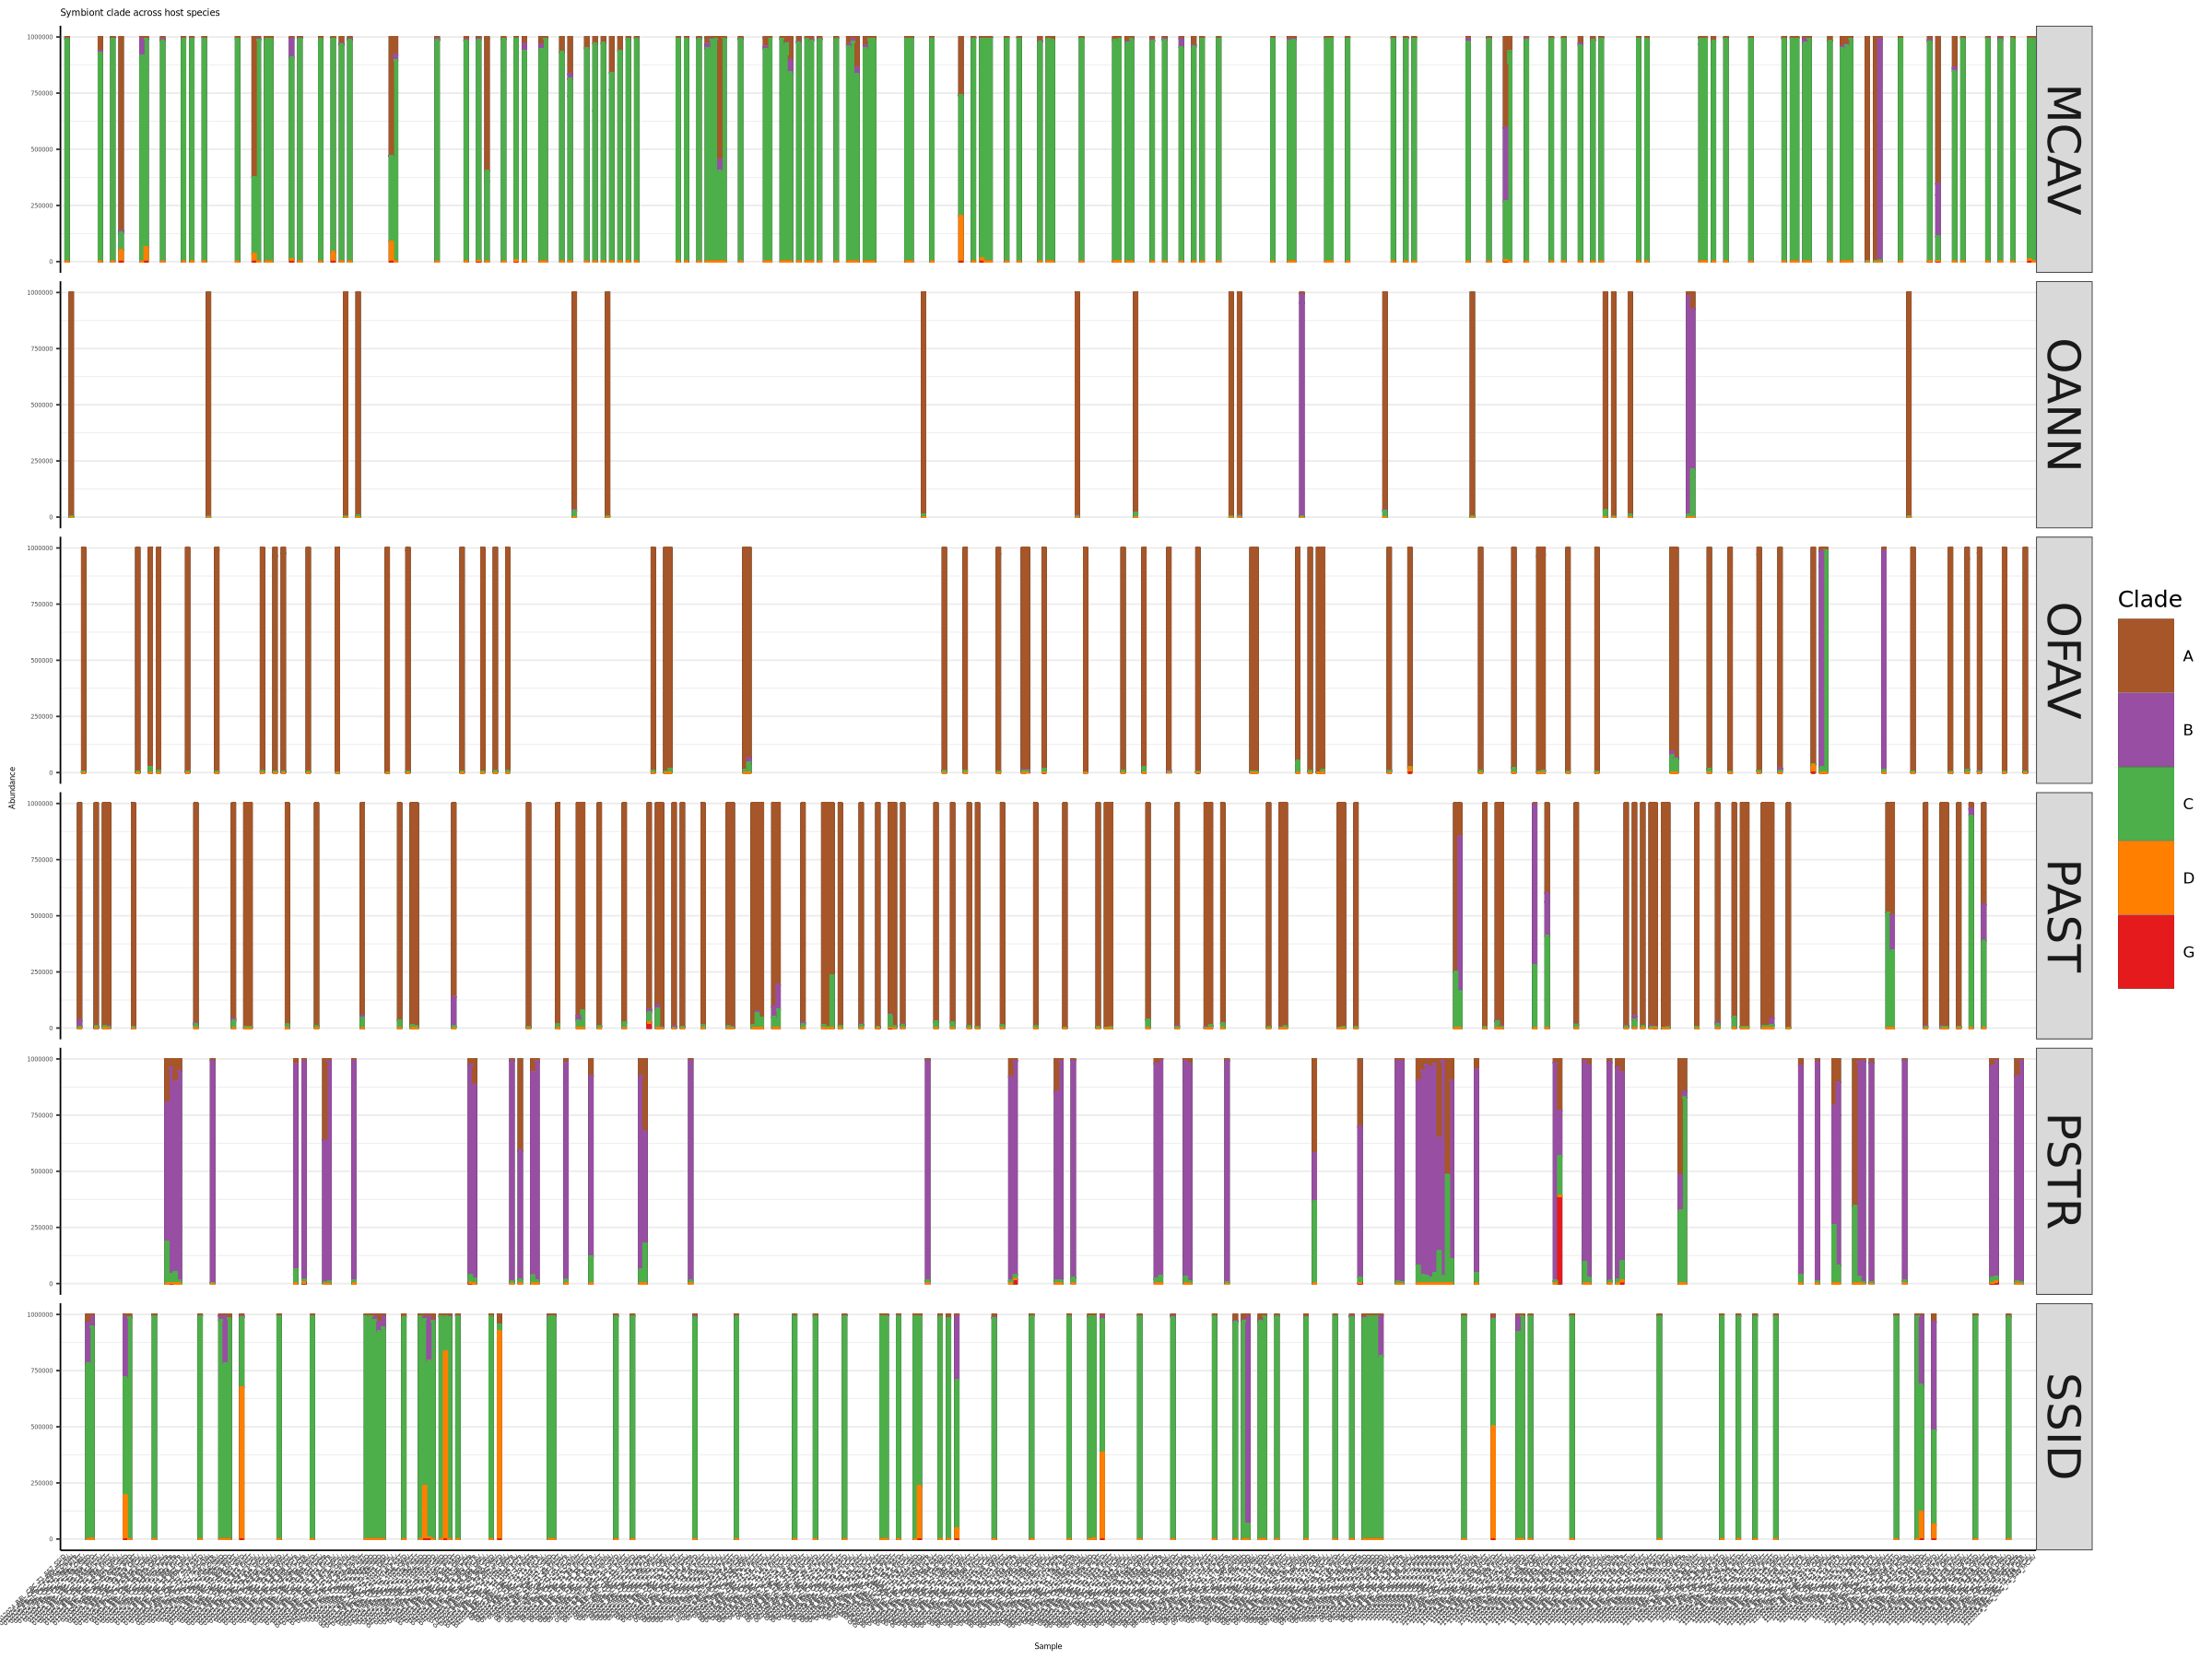

In [54]:
clade <- plot_bar(ps_clade, fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_y") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Sample",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 30), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 5)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
clade

### by colony facetted by species

<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”


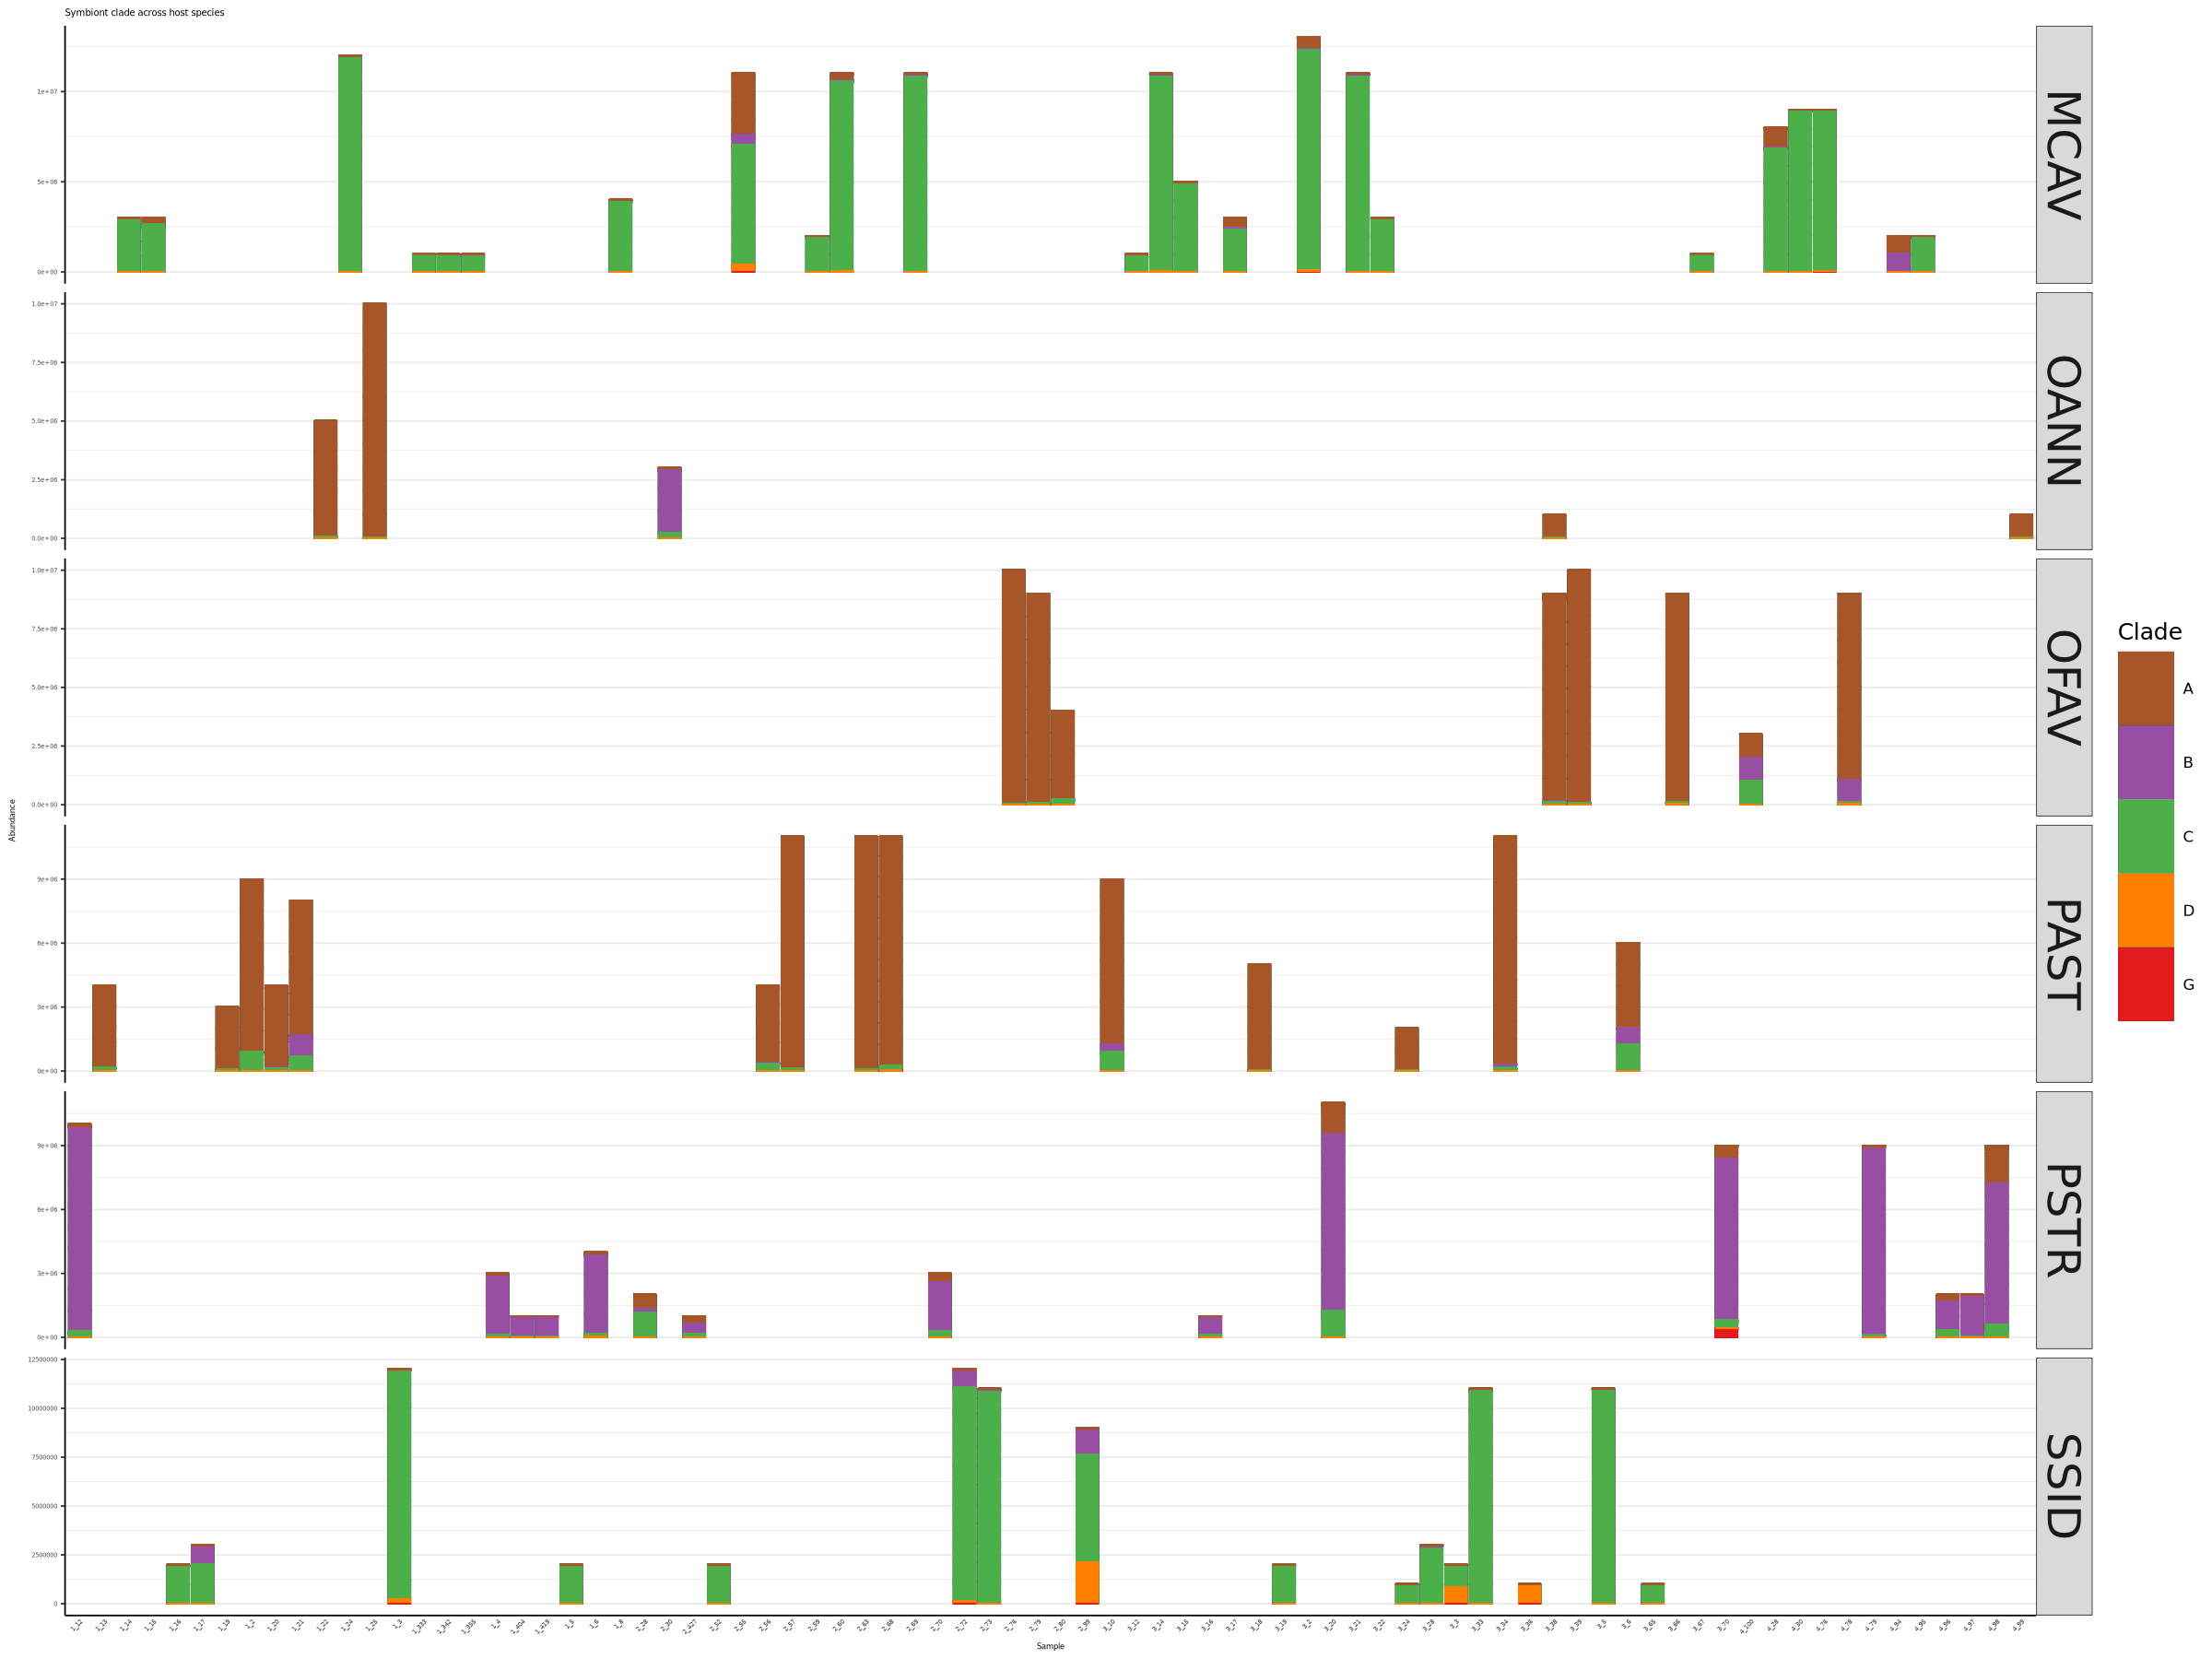

In [55]:

col_clade <- plot_bar(ps_clade,x= "colony", fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_y") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Sample",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 30), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 5)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
col_clade

## its2 profile

may be a good idea to make the its2 profiles a range of colors based on each clade

In [56]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_norm)[, "ITS2.type.profile"]))

[1] 264

In [57]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_norm)[, "Majority.ITS2.sequence"]))

[1] 63

In [58]:
## colors

## make the ITS2 colors correspond with cladecolors

In [59]:
# Extract ITS2 profiles and clades directly from phyloseq object
its2 <- psmelt(ps_norm)

profiles <- unique(as.character(its2$Majority.ITS2.sequence))
profiles <- trimws(profiles)
profiles <- profiles[!is.na(profiles)]

# Extract clade letter from each profile (e.g., "A3" -> "A")
clade <- substr(profiles, 1, 1)


In [60]:
#shift base color toward white
lighten_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  lighter <- rgb_col + (1 - rgb_col) * factor
  rgb(lighter[1], lighter[2], lighter[3])
}

In [61]:
#shift base color towards black
darken_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  darker <- rgb_col * (1 - factor)
  rgb(darker[1], darker[2], darker[3])
}

In [62]:
profile_colors <- list()

for (cl in unique(clade)) {

  cl_profiles <- profiles[clade == cl]
  n <- length(cl_profiles)

  if (n > 0) {

    base_col <- cladecolors[[cl]]
    light_col <- lighten_color(base_col, 0.5)
    dark_col <- darken_color(base_col, 0.5) 

    ramp <- colorRampPalette(c(light_col, base_col, dark_col))(n)

    profile_colors[[cl]] <- setNames(ramp, cl_profiles)
  }
}

profile_colors <- unlist(profile_colors)

In [63]:
names(profile_colors) <- sub("^[A-Z]\\.", "", names(profile_colors))

In [64]:
# inspect plotting issues 
unique(its2$Majority.ITS2.sequence)[1:20]
head(names(profile_colors), 20)

[1] "A3"        "A3/A4"     "A4a"       "C3"        "C1"        "A4"       
 [7] "C3cd/C3"   "A4a/A4"    "C21/C3"    "A3/A4a"    "C21"       "A3/A4/A4a"
[13] "B1"        "A4/A3/A4a" "A4/A4a"    "C1/C3"     "B1/B14d"   "B14d/B1"  
[19] "B1/B1be"   "B14d"

[1] "A3"            "A3/A4"         "A4a"           "A4"           
 [5] "A4a/A4"        "A3/A4a"        "A3/A4/A4a"     "A4/A3/A4a"    
 [9] "A4/A4a"        "A4/A3"         "A13"           "A3/A4/A13/A4a"
[13] "A3/A4/A13"     "A3/A4a/A13"    "A3/A13"        "A4z"          
[17] "A3bb/A3bt"     "A3bb"          "A1pp"          "C3"

In [ ]:
col_clade <- plot_bar(ps_clade,x= "colony", fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_y") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Sample",
       y = "Abundance",
       color = "Clade") +

<Guides[1] ggproto object>

colour : <GuideLegend>

Ignoring unknown labels:
• colour : "Majority.ITS2.sequence"
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”


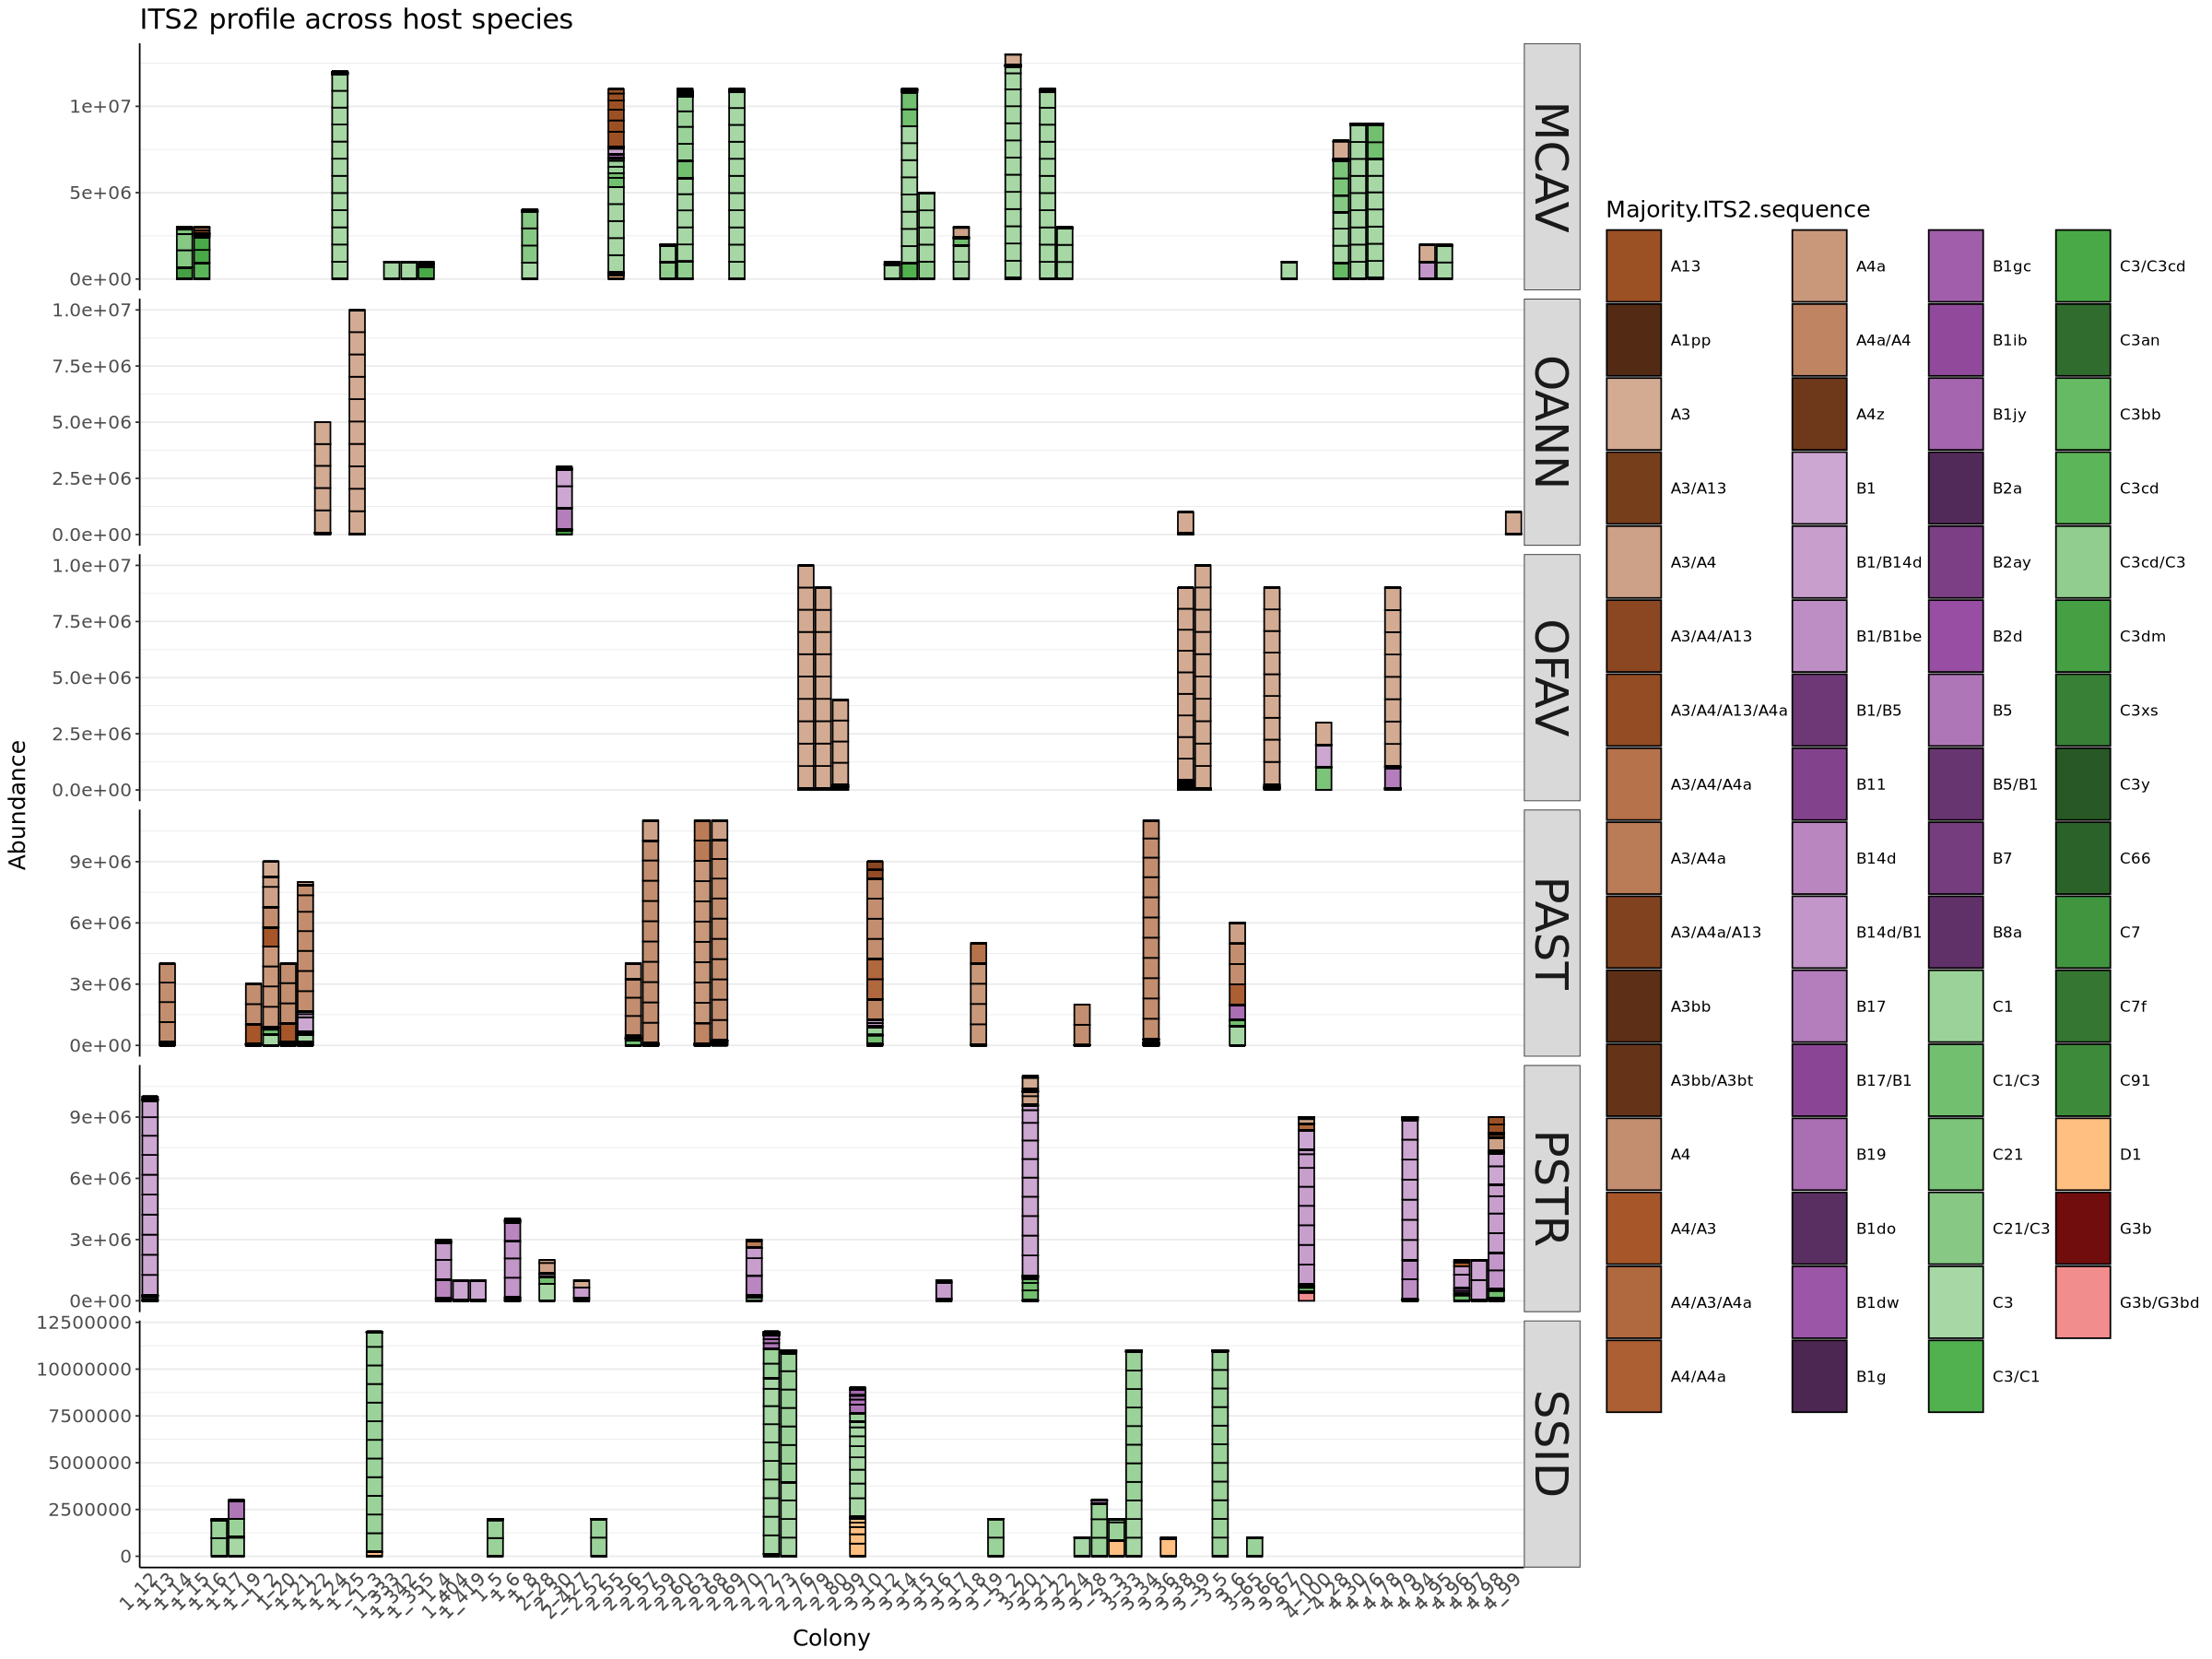

In [66]:
col_profile <- plot_bar(ps_norm, x = "colony", fill = "Majority.ITS2.sequence") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_y") + # Set desired font size
  labs(title = "ITS2 profile across host species",
       x = "Colony",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 30), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 15)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
col_profile

<Guides[1] ggproto object>

colour : <GuideLegend>

Ignoring unknown labels:
• colour : "Majority.ITS2.sequence"
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“Removed 1251 rows containing missing values or values outside the scale range
(`geom_bar()`).”


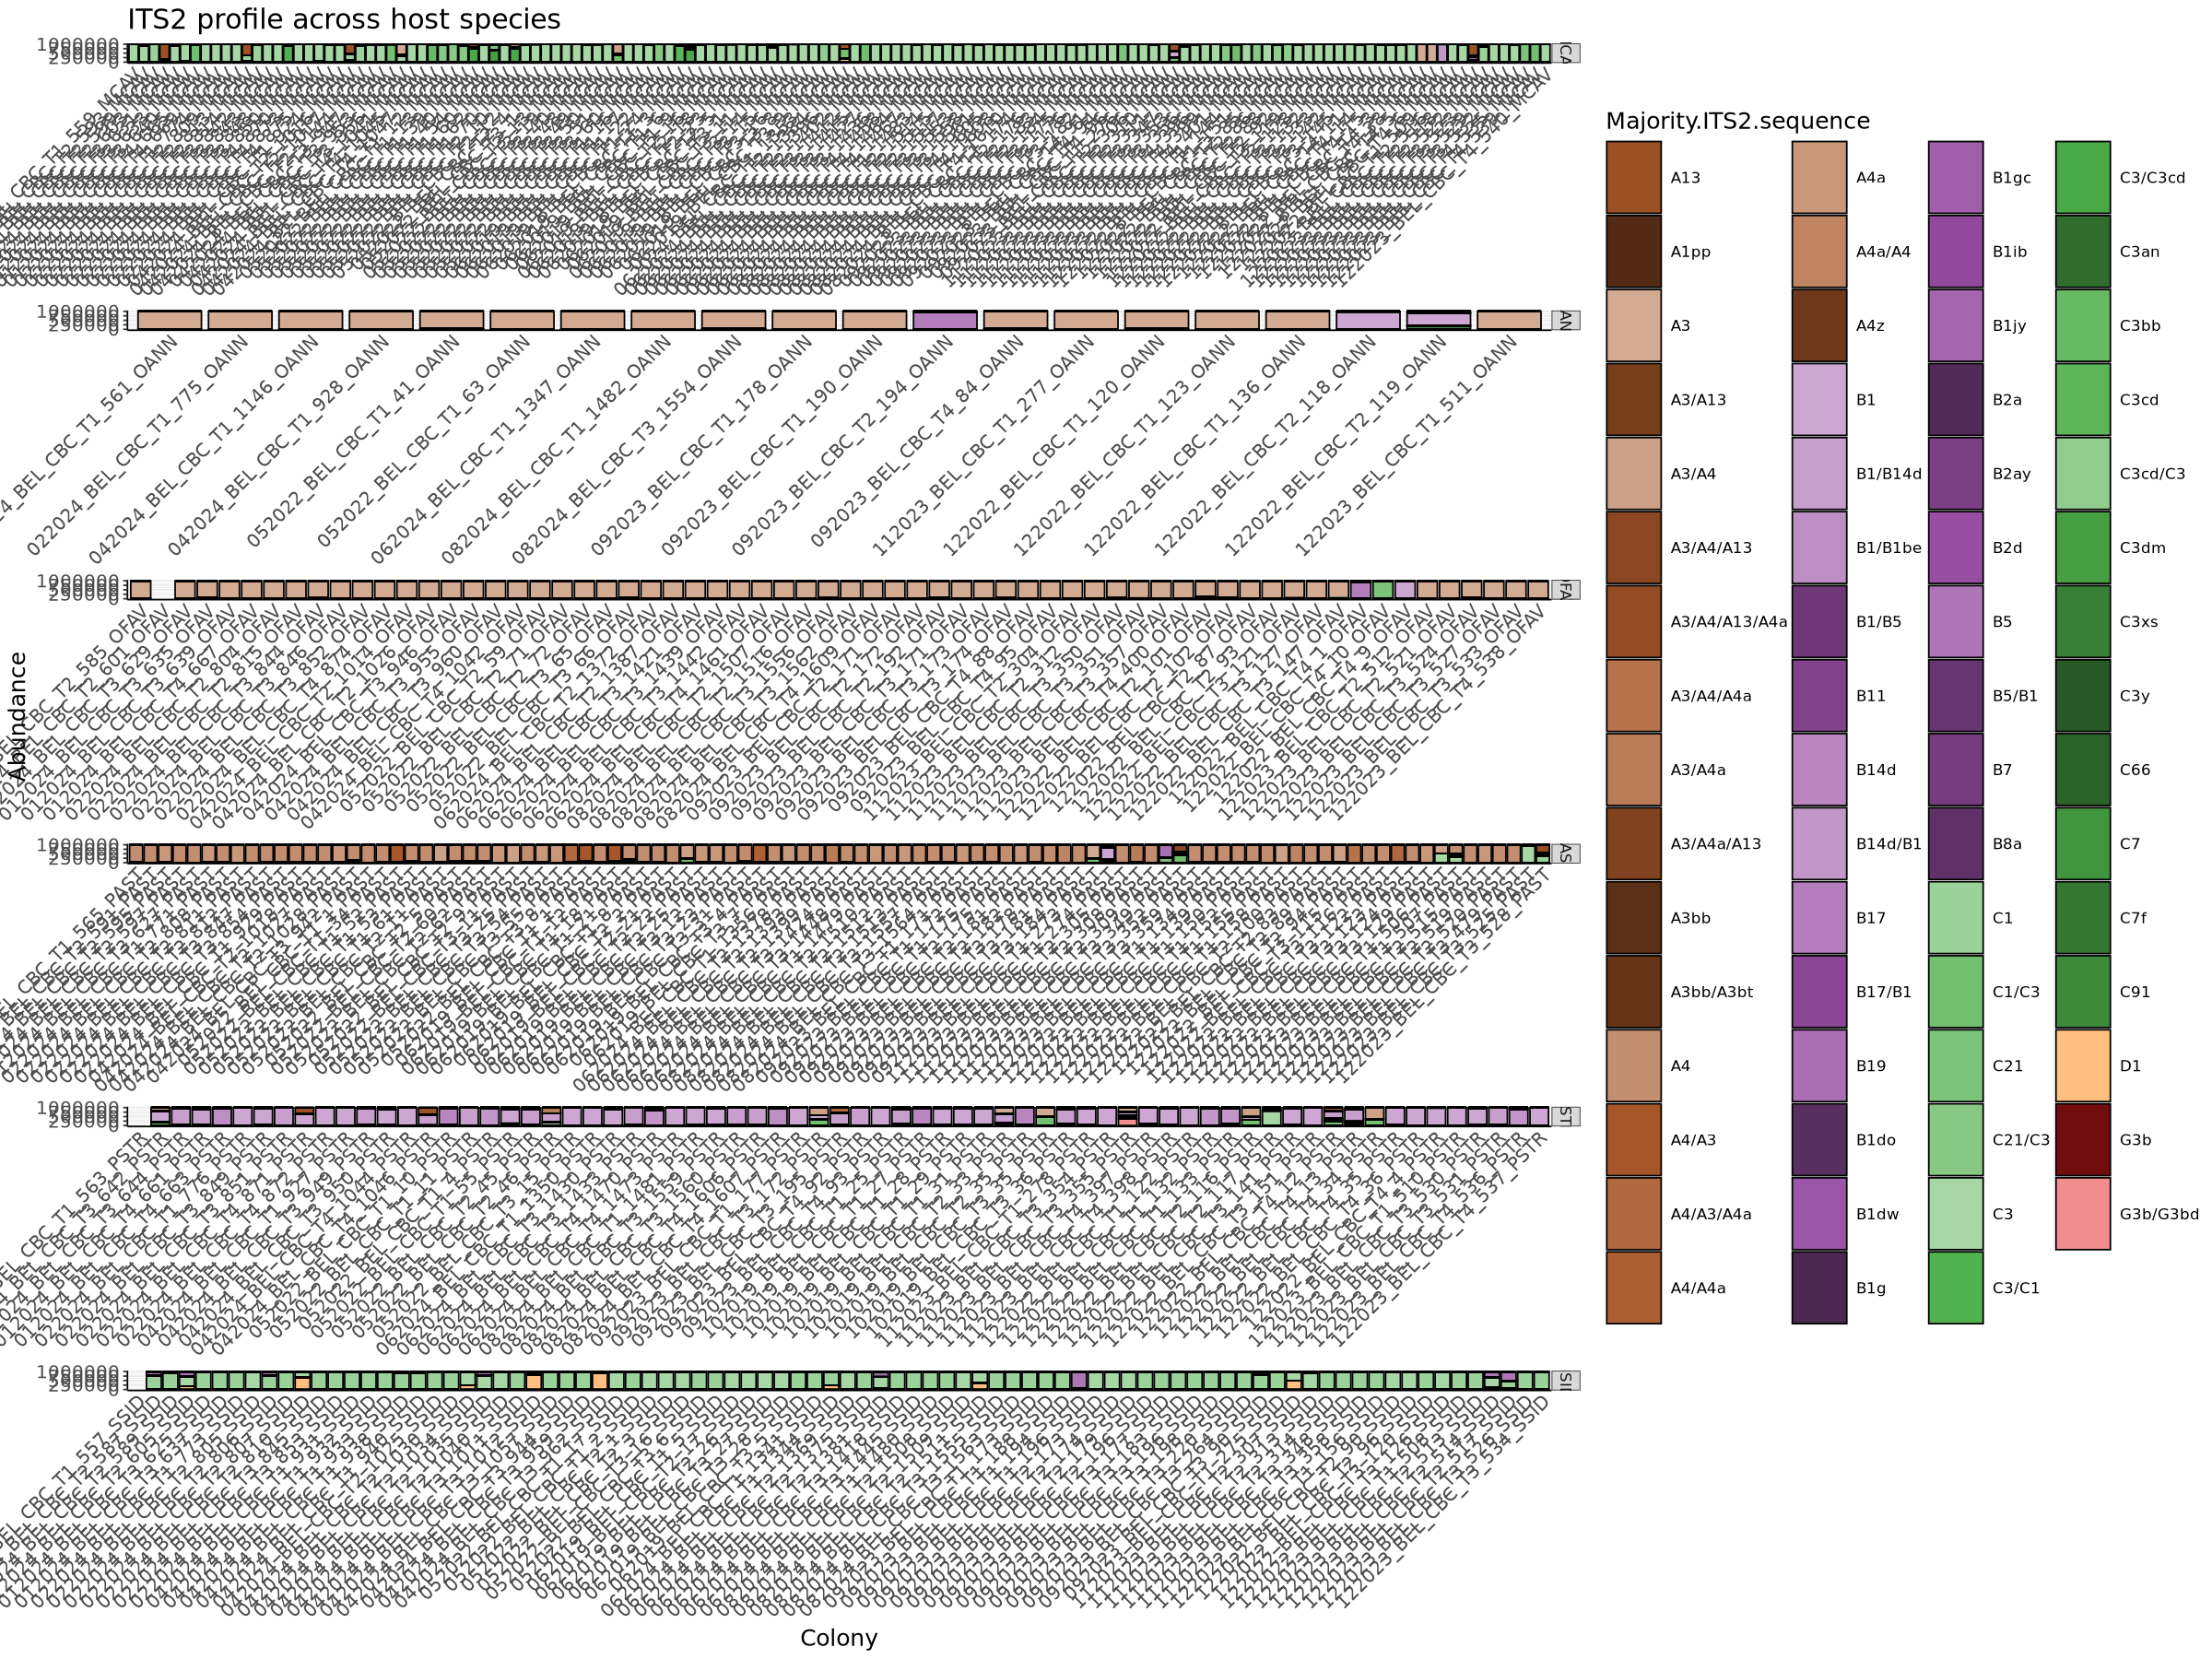

In [71]:
sam_profile <- plot_bar(ps_norm, fill = "Majority.ITS2.sequence") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_x") + # Set desired font size
  labs(title = "ITS2 profile across host species",
       x = "Colony",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 10), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 15)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
sam_profile